# 📘 Module 42 — Deep Learning Debugging
## Part 2: Model Problems — Revision Notes

These notes cover **only the Model Problems section** of Module 42, matching our syllabus position. syllabus

---

# 1️⃣ Wrong Output Shape



### 🎯 Core idea

The model's output shape must match:

**Task → Target/label shape → Loss function**

For classification:

```text
Input
  ↓
Neural Network
  ↓
Output logits
  ↓
Expected target
```

### Common shapes

| Task | Typical output |
|---|---|
| Binary classification | `[B, 1]` or `[B]` |
| Multiclass classification | `[B, C]` |
| Regression | `[B, 1]` |
| Segmentation | `[B, C, H, W]` |

Where:

- `B` = batch size
- `C` = number of classes
- `H, W` = image height and width

### 🚨 Debugging symptom

You may see:

```text
Expected input batch_size to match target batch_size
```

or

```text
Target size must be the same as input size
```

### 🔍 First thing to inspect

```python
print(x.shape)
print(y.shape)
print(output.shape)
```

---

# 2️⃣ Wrong Activation



The activation must make sense for the **prediction task**.

### Binary classification

Conceptually:

```text
logits → sigmoid → probability
```

Example:

```text
0.87 → 87% probability of class 1
```

### Multiclass classification

Conceptually:

```text
logits → softmax → class probabilities
```

Example:

```text
Cat       0.05
Dog       0.90
Horse     0.05
```

### Regression

Usually:

```text
logits → linear output
```

No probability activation is required.

---

## ⚠️ Important PyTorch rule

When using:

```python
nn.CrossEntropyLoss()
```

the model normally outputs **raw logits**:

```python
output = model(x)
loss = criterion(output, y)
```

❌ Don't normally do:

```python
output = softmax(model(x))
loss = criterion(output, y)
```

`CrossEntropyLoss` internally handles the appropriate log-softmax operation.

---

# 3️⃣ Wrong Loss Function



The loss function must match the **task + target representation + model output**.

### Common pairings

| Problem | Typical loss |
|---|---|
| Regression | MSE / MAE / Huber |
| Multiclass classification | CrossEntropyLoss |
| Binary classification | BCEWithLogitsLoss |
| Multilabel classification | BCEWithLogitsLoss |

### Example

For multiclass classification:

```python
criterion = nn.CrossEntropyLoss()

logits = model(x)      # [B, C]
loss = criterion(logits, y)
```

Typical target:

```text
logits → [B, C]
target → [B]
```

where each target value is a class index.

---

# 4️⃣ Exploding Gradients 💥



### What happens?

Gradients become **extremely large**.

```text
Normal:
gradient → 0.01 → 0.02 → 0.03

Exploding:
gradient → 2 → 50 → 10000 → ∞
```

This can cause:

- unstable training
- huge parameter updates
- loss suddenly increasing
- `NaN`
- `Inf`
- model failure

### 🔍 Debugging

Inspect gradients:

```python
for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm())
```

If gradient norms become extremely large, you may have an exploding-gradient problem.

### 🛠️ Possible remedies

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

Other possibilities include:

- appropriate learning rate
- better initialization
- normalization
- suitable activation functions
- appropriate architecture

---

# 5️⃣ Vanishing Gradients 🫥



### What happens?

Gradients become **extremely small** as they propagate backward.

```text
Later layer:
0.1

↓
0.01

↓
0.001

↓
0.00001

↓
0.0000001
```

Eventually, earlier layers receive almost no useful learning signal.

### 🚨 Symptoms

- early layers barely change
- training becomes extremely slow
- loss stops improving effectively
- some parameters have gradients close to zero

### 🔍 Debugging

```python
for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm().item())
```

Look for layers whose gradients are consistently extremely small.

### 🧠 Important connection

You already studied the **theory of vanishing/exploding gradients in Module 9**.

Here, the important skill is:

> **Recognize the symptom → inspect gradients → identify the problematic layers → apply an appropriate fix.**

---

# 🧠 Model Debugging Mental Model



When the model behaves strangely, check in this order:

```text
             MODEL PROBLEM
                   │
        ┌──────────┴──────────┐
        ↓                     ↓
   Output Shape?          Activation?
        │                     │
        ↓                     ↓
   Correct dimensions?   Correct task?
        │
        └──────────┬──────────┘
                   ↓
              Correct Loss?
                   ↓
             Check Gradients
                   ↓
       ┌───────────┴───────────┐
       ↓                       ↓
 Large gradients         Tiny gradients
       ↓                       ↓
 Exploding gradients     Vanishing gradients
```
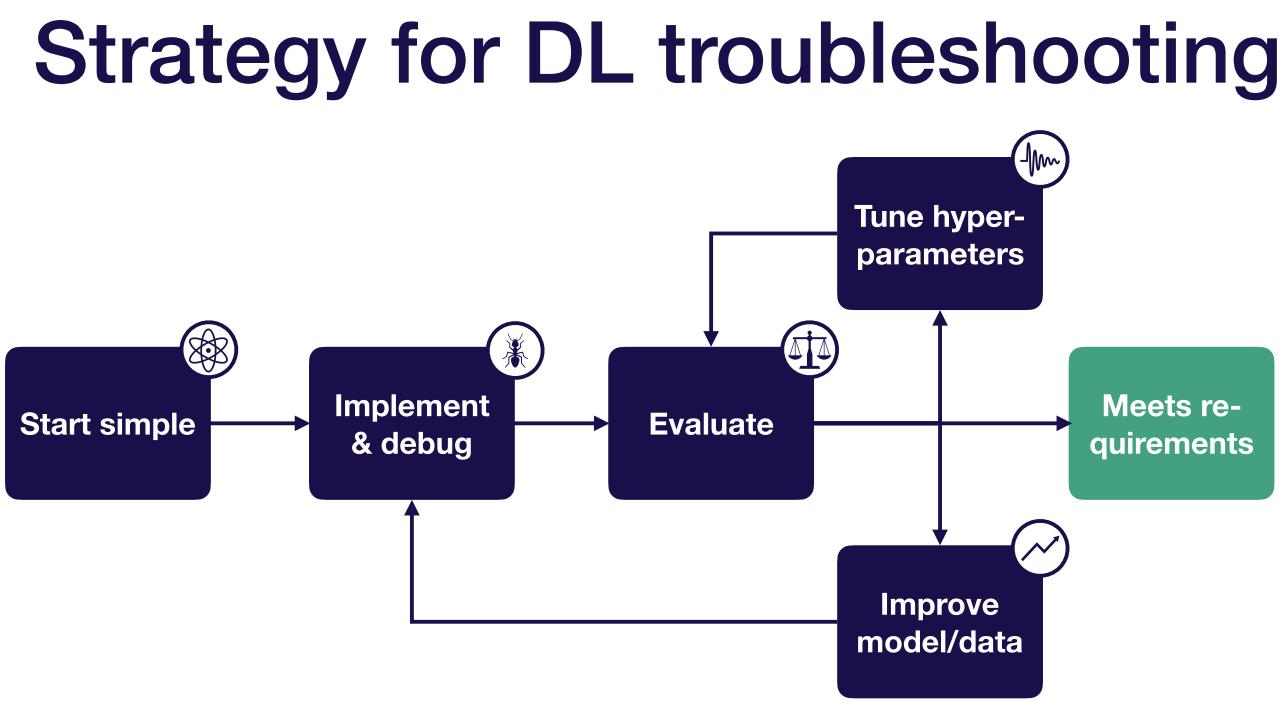
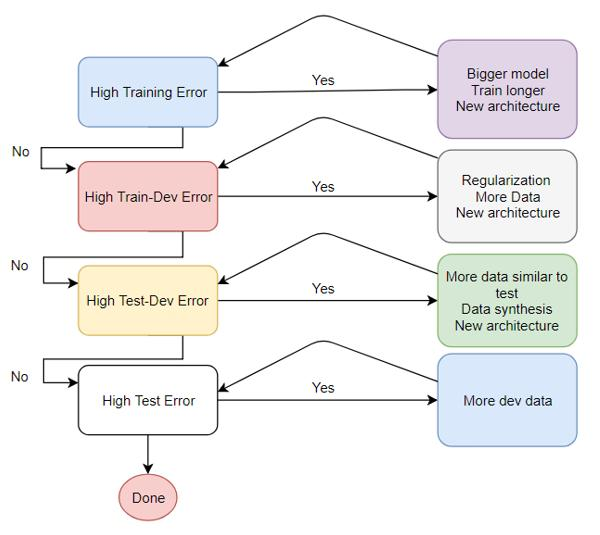
---

# 🔥 One-Page Debugging Table

| Problem | Main symptom | First thing to check |
|---|---|---|
| ❌ Wrong output shape | Shape/loss errors | `output.shape`, `target.shape` |
| ❌ Wrong activation | Bad predictions/training | Task ↔ activation |
| ❌ Wrong loss | Model trains poorly / incompatible targets | Task ↔ output ↔ target ↔ loss |
| 💥 Exploding gradients | Huge updates, `NaN/Inf` | Gradient norms |
| 🫥 Vanishing gradients | Early layers barely learn | Layer-wise gradient norms |

---

# 🧩 The Most Important Rule

Whenever a model fails, **don't immediately change random hyperparameters**.

Think:

```text
INPUT
  ↓
OUTPUT SHAPE
  ↓
ACTIVATION
  ↓
TARGET
  ↓
LOSS
  ↓
GRADIENTS
  ↓
TRAINING BEHAVIOR
```

A large part of deep-learning debugging is simply finding **where this chain stops making sense**.

---
